In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# Top 5 biggest companies in the world
stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
stock_names = {
    'AAPL': 'Apple',
    'GOOGL': 'Google', 
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'TSLA': 'Tesla'
}

# Download 5 years of data automatically from internet
print("Downloading live stock data...")
df = yf.download(stocks, start='2019-01-01', end='2024-01-01')
print("✅ Data downloaded successfully!")
print("Shape:", df.shape)
df.head()

[*********************100%***********************]  5 of 5 completed

✅ Data downloaded successfully!
Shape: (1258, 25)


Price           Close                                                   High  \
Ticker           AAPL       AMZN      GOOGL       MSFT       TSLA       AAPL   
Date                                                                           
2019-01-02  37.469189  76.956497  52.301731  94.397156  20.674667  37.689849   
2019-01-03  33.736996  75.014000  50.853199  90.924477  20.024000  34.574548   
2019-01-04  35.177208  78.769501  53.461639  95.153305  21.179333  35.246017   
2019-01-07  35.098907  81.475502  53.355019  95.274643  22.330667  35.312450   
2019-01-08  35.768002  82.829002  53.823647  95.965462  22.356667  36.021879   

Price                                                   ...       Open  \
Ticker           AMZN      GOOGL       MSFT       TSLA  ...       AAPL   
Date                                                    ...              
2019-01-02  77.667999  52.604727  94.985268  21.008667  ...  36.750270   
2019-01-03  76.900002  52.875982  93.528988  20.626667  ...  34.161702   
2019-01-04  79.699997  53.557349  95.694746  21.200001  ...  34.292203   
2019-01-07  81.727997  53.691237  96.404196  22.449333  ...  35.281604   
2019-01-08  83.830498  54.219374  97.057674  22.934000  ...  35.485653   

Price                                                      Volume             \
Ticker           AMZN      GOOGL       MSFT       TSLA       AAPL       AMZN   
Date                                                                           
2019-01-02  73.260002  50.938993  92.931536  20.406668  148158800  159662000   
2019-01-03  76.000504  52.102873  93.444967  20.466667  365248800  139512000   
2019-01-04  76.500000  51.700692  93.090235  20.400000  234428400  183652000   
2019-01-07  80.115501  53.605447  94.882568  21.448000  219111200  159864000   
2019-01-08  83.234497  53.854886  96.189504  22.797333  164101200  177628000   

Price                                      
Ticker         GOOGL      MSFT       TSLA  
Date                                       
2019-01-02  31868000  35329300  174879000  
2019-01-03  41960000  42579100  104478000  
2019-01-04  46022000  44060600  110911500  
2019-01-07  47446000  35656100  113268000  
2019-01-08  35414000  31514400  105127500  

[5 rows x 25 columns]

In [3]:
# Get only closing prices
close_df = df['Close']
close_df = close_df.dropna()

print("✅ Data cleaned!")
print("Total trading days:", len(close_df))
print("\nFirst few rows:")
close_df.head()

✅ Data cleaned!
Total trading days: 1258

First few rows:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2019-01-02,37.469189,76.956497,52.301731,94.397156,20.674667
2019-01-03,33.736996,75.014000,50.853199,90.924477,20.024000
2019-01-04,35.177208,78.769501,53.461639,95.153305,21.179333
2019-01-07,35.098907,81.475502,53.355019,95.274643,22.330667
2019-01-08,35.768002,82.829002,53.823647,95.965462,22.356667


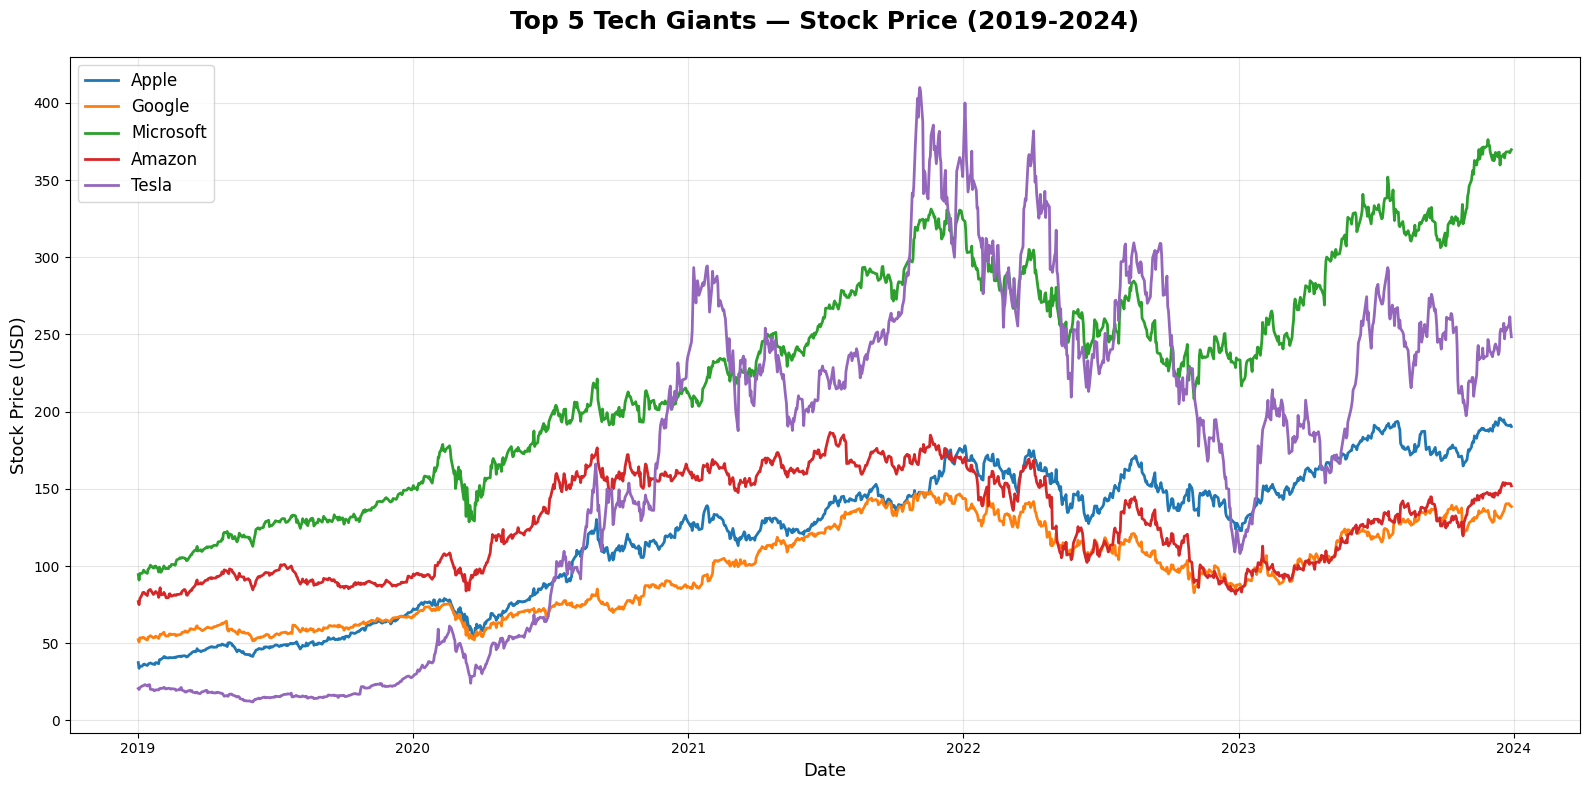

✅ Chart 1 saved!


In [4]:
plt.figure(figsize=(16, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, stock in enumerate(stocks):
    plt.plot(close_df.index, close_df[stock], 
             label=stock_names[stock], 
             linewidth=2, color=colors[i])

plt.title('Top 5 Tech Giants — Stock Price (2019-2024)', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Stock Price (USD)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_prices.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

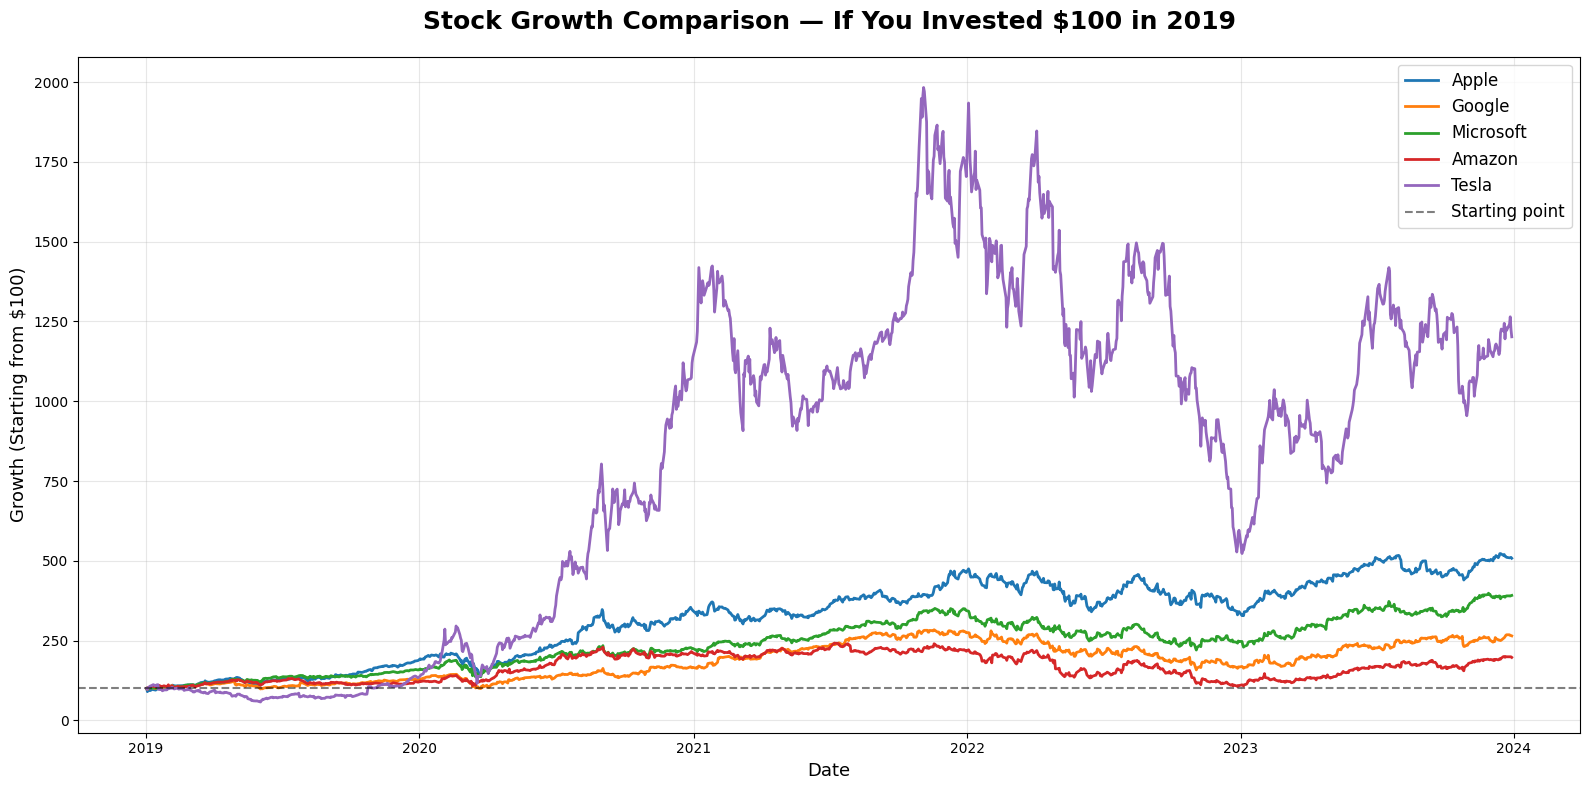

✅ Chart 2 saved!


In [5]:
# Normalize to 100 so we can compare growth
normalized = (close_df / close_df.iloc[0]) * 100

plt.figure(figsize=(16, 8))

for i, stock in enumerate(stocks):
    plt.plot(normalized.index, normalized[stock],
             label=stock_names[stock],
             linewidth=2, color=colors[i])

plt.axhline(y=100, color='black', linestyle='--', 
            alpha=0.5, label='Starting point')
plt.title('Stock Growth Comparison — If You Invested $100 in 2019', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Growth (Starting from $100)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_growth.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

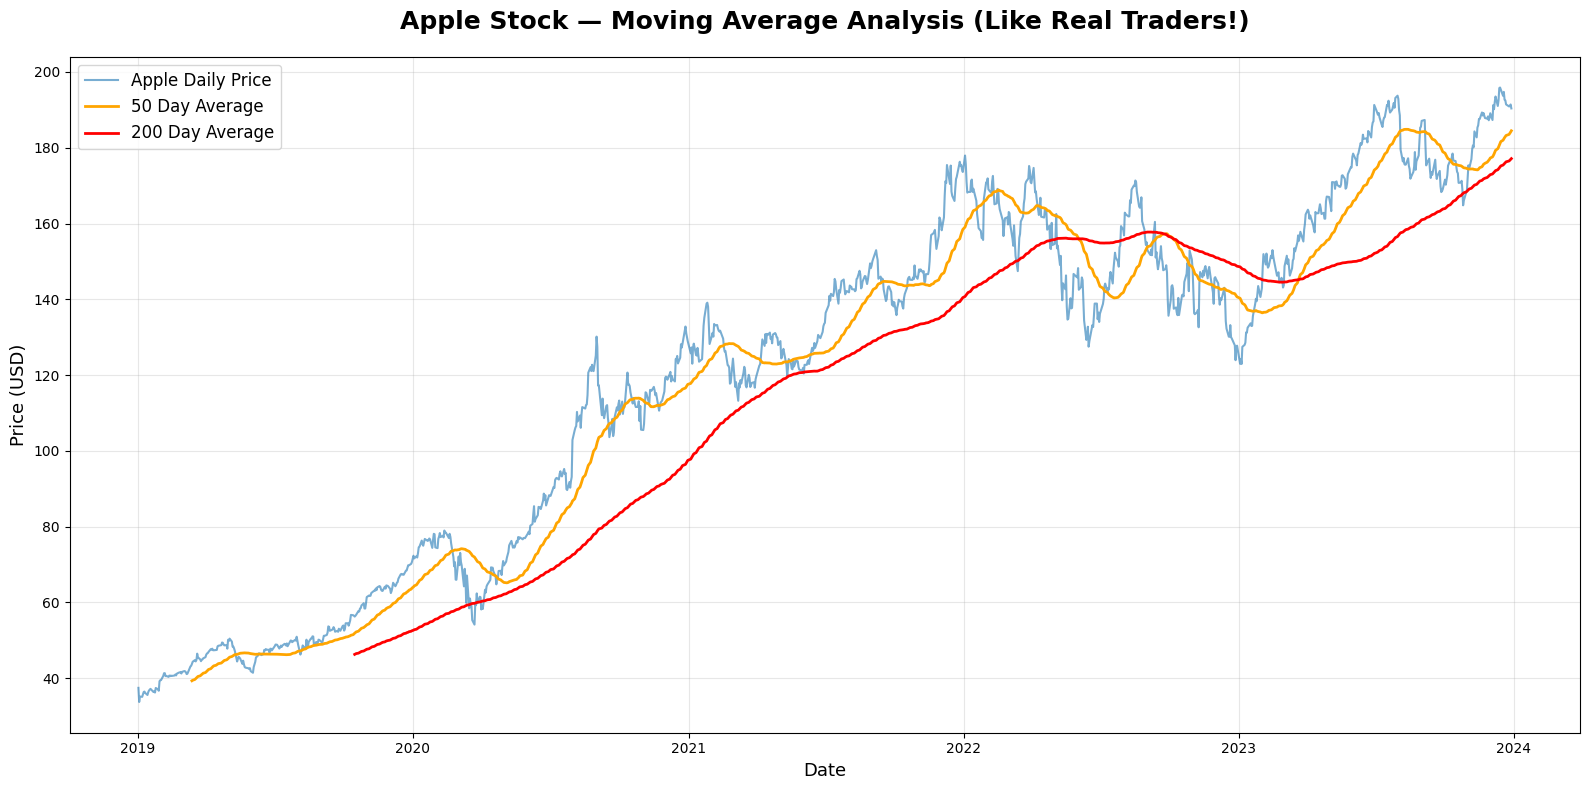

✅ Chart 3 saved!


In [6]:
apple = close_df['AAPL'].copy().to_frame()

# Moving averages — this is what real stock traders use!
apple['50_day_avg'] = apple['AAPL'].rolling(50).mean()
apple['200_day_avg'] = apple['AAPL'].rolling(200).mean()

plt.figure(figsize=(16, 8))
plt.plot(apple.index, apple['AAPL'], 
         label='Apple Daily Price', alpha=0.6, color='#1f77b4')
plt.plot(apple.index, apple['50_day_avg'], 
         label='50 Day Average', linewidth=2, color='orange')
plt.plot(apple.index, apple['200_day_avg'], 
         label='200 Day Average', linewidth=2, color='red')

plt.title('Apple Stock — Moving Average Analysis (Like Real Traders!)', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Price (USD)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('apple_moving_avg.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

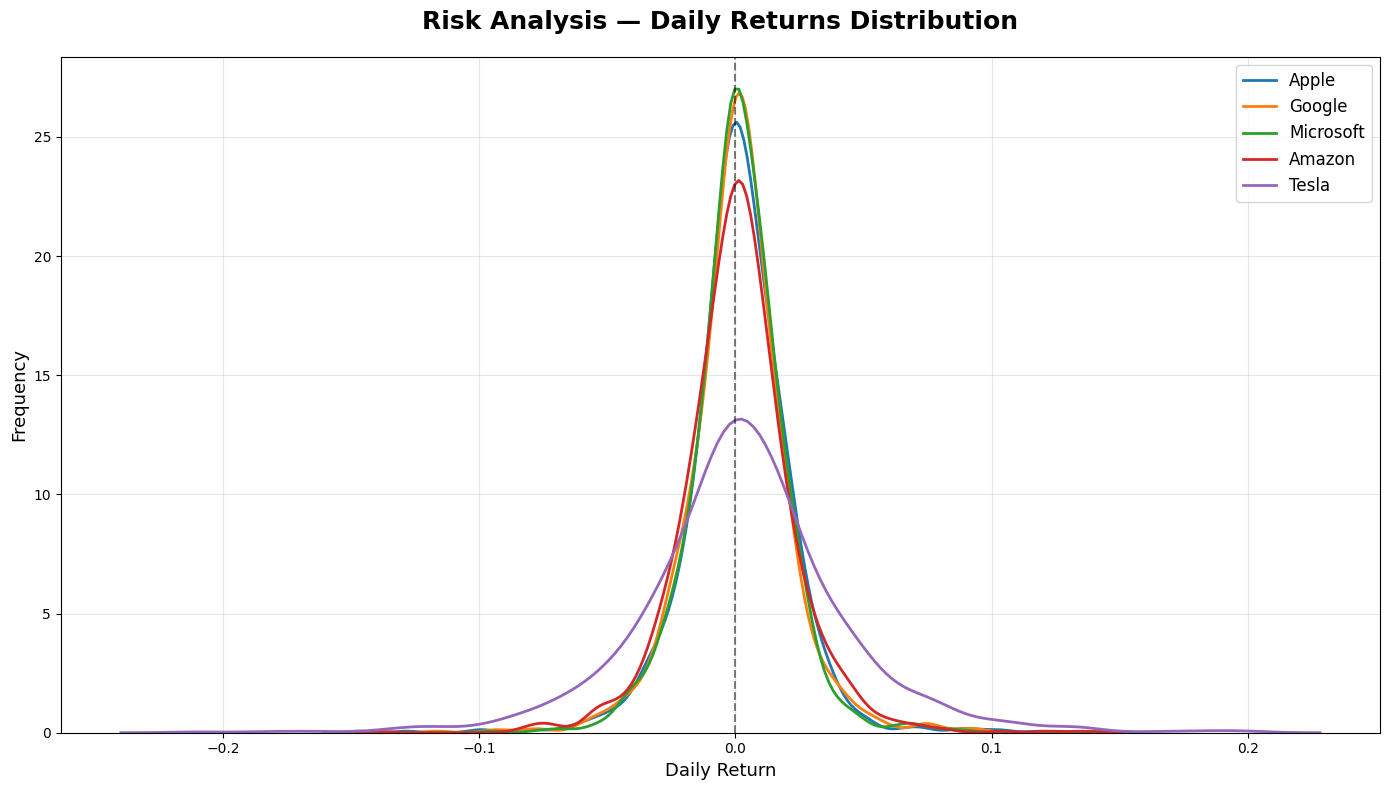

✅ Chart 4 saved!


In [7]:
# Calculate daily returns
daily_returns = close_df.pct_change().dropna()

plt.figure(figsize=(14, 8))
for i, stock in enumerate(stocks):
    sns.kdeplot(daily_returns[stock], 
                label=stock_names[stock],
                linewidth=2, color=colors[i])

plt.title('Risk Analysis — Daily Returns Distribution', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Daily Return', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

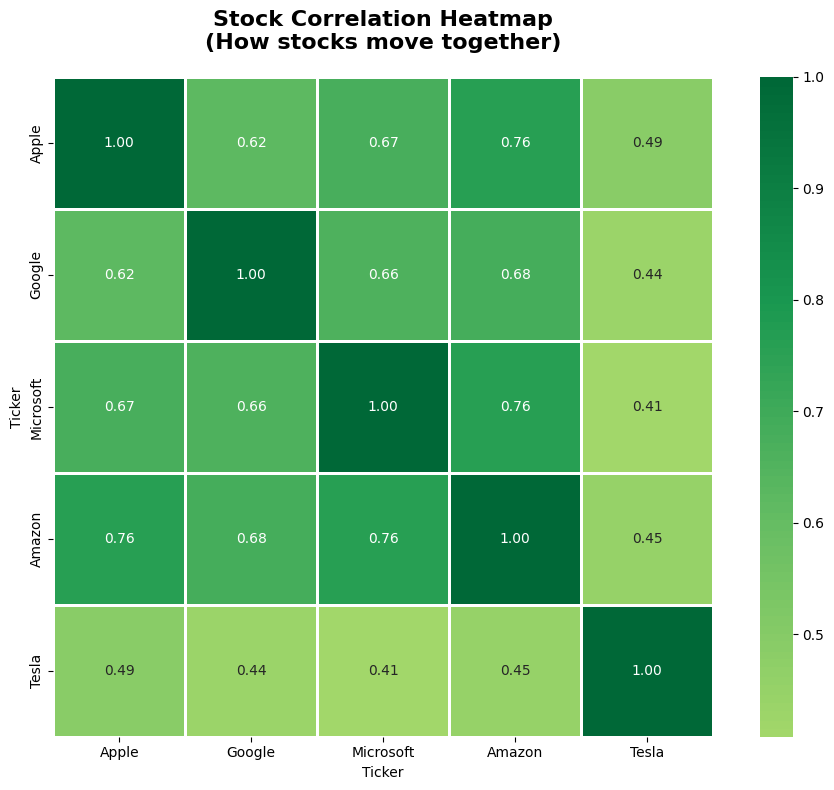

✅ Chart 5 saved!


In [8]:
plt.figure(figsize=(10, 8))
correlation = daily_returns.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=1,
            xticklabels=list(stock_names.values()),
            yticklabels=list(stock_names.values()))

plt.title('Stock Correlation Heatmap\n(How stocks move together)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

In [9]:
print("=" * 65)
print("   STOCK MARKET ANALYSIS — KEY FINDINGS")
print("=" * 65)

# Total growth of each stock
total_growth = ((close_df.iloc[-1] - close_df.iloc[0]) / close_df.iloc[0] * 100).round(2)
best_stock = total_growth.idxmax()
worst_stock = total_growth.idxmin()

print("\n📈 Total Growth from 2019 to 2024:")
for stock in stocks:
    print(f"   {stock_names[stock]:12} : {total_growth[stock]:>8.2f}%")

print(f"\n🏆 Best performer  : {stock_names[best_stock]} ({total_growth[best_stock]:.2f}%)")
print(f"⚠️  Worst performer : {stock_names[worst_stock]} ({total_growth[worst_stock]:.2f}%)")

avg_volatility = daily_returns.std() * 100
riskiest = avg_volatility.idxmax()
print(f"\n⚡ Riskiest stock   : {stock_names[riskiest]} (most ups and downs)")
print(f"\n✅ All 5 charts saved successfully!")
print(f"✅ Stock Market Analysis complete MD. Yamama!")

   STOCK MARKET ANALYSIS — KEY FINDINGS

📈 Total Growth from 2019 to 2024:
   Apple        :   408.08%
   Google       :   164.90%
   Microsoft    :   291.61%
   Amazon       :    97.44%
   Tesla        :  1101.86%

🏆 Best performer  : Tesla (1101.86%)
⚠️  Worst performer : Amazon (97.44%)

⚡ Riskiest stock   : Tesla (most ups and downs)

✅ All 5 charts saved successfully!
✅ Stock Market Analysis complete MD. Yamama!


In [10]:
import shutil, os

src = r'C:\Users\yamam'
dst = r'C:\Users\yamam\OneDrive\Desktop'

files = [
    'stock_prices.png',
    'stock_growth.png',
    'apple_moving_avg.png',
    'risk_analysis.png',
    'correlation_heatmap.png'
]

for f in files:
    src_file = os.path.join(src, f)
    dst_file = os.path.join(dst, f)
    if os.path.exists(src_file):
        shutil.copy(src_file, dst_file)
        print(f"✅ Copied: {f}")
    else:
        print(f"❌ Not found: {f}")

print("\n✅ All files copied to Desktop!")

✅ Copied: stock_prices.png
✅ Copied: stock_growth.png
✅ Copied: apple_moving_avg.png
✅ Copied: risk_analysis.png
✅ Copied: correlation_heatmap.png

✅ All files copied to Desktop!
